In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import random
from skimage.filters import threshold_sauvola, threshold_niblack
from joblib import Parallel, delayed
import json
from datetime import datetime
import IPython.display as display
from PIL import Image
import io
import time
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from skimage.feature import hog
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
import urllib.request
from pathlib import Path
import tensorflow as tf
import requests
from tqdm import tqdm

%matplotlib inline

In [10]:
from tensorflow.keras.datasets import cifar10

# Load dataset locally
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Successfully loaded CIFAR-10 from local .keras folder!")
print(f"Training images shape: {X_train.shape}")  # (50000, 32, 32, 3)
print(f"Testing images shape : {X_test.shape}")   # (10000, 32, 32, 3)

Successfully loaded CIFAR-10 from local .keras folder!
Training images shape: (50000, 32, 32, 3)
Testing images shape : (10000, 32, 32, 3)


Dataset ready: 50000 train samples, 10000 test samples.

 1. BUILDING & TRAINING BASELINE MLP


c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "CIFAR10_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,898 (1.38 MB)

 Trainable params: 361,898 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.4603 - loss: 1.4903 - val_accuracy: 0.5864 - val_loss: 1.1642
Epoch 2/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - accuracy: 0.6158 - loss: 1.0874 - val_accuracy: 0.6740 - val_loss: 0.9360
Epoch 3/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.6852 - loss: 0.8977 - val_accuracy: 0.7052 - val_loss: 0.8476
Epoch 4/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7327 - loss: 0.7682 - val_accuracy: 0.6990 - val_loss: 0.8664
Epoch 5/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7677 - loss: 0.6602 - val_accuracy: 0.7154 - val_loss: 0.8492
Epoch 6/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7938 - loss: 0.5847 - val_accuracy: 0.7570 - val_loss: 0.7085
Epoch 7/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 50s 72ms/step - accuracy: 0.8245 - loss: 0.5040 - val_accuracy: 0.7602 - val_loss: 0.7294
Epoch 8/15
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 80ms/step - accuracy: 0.8505 - loss: 0.4296 - 

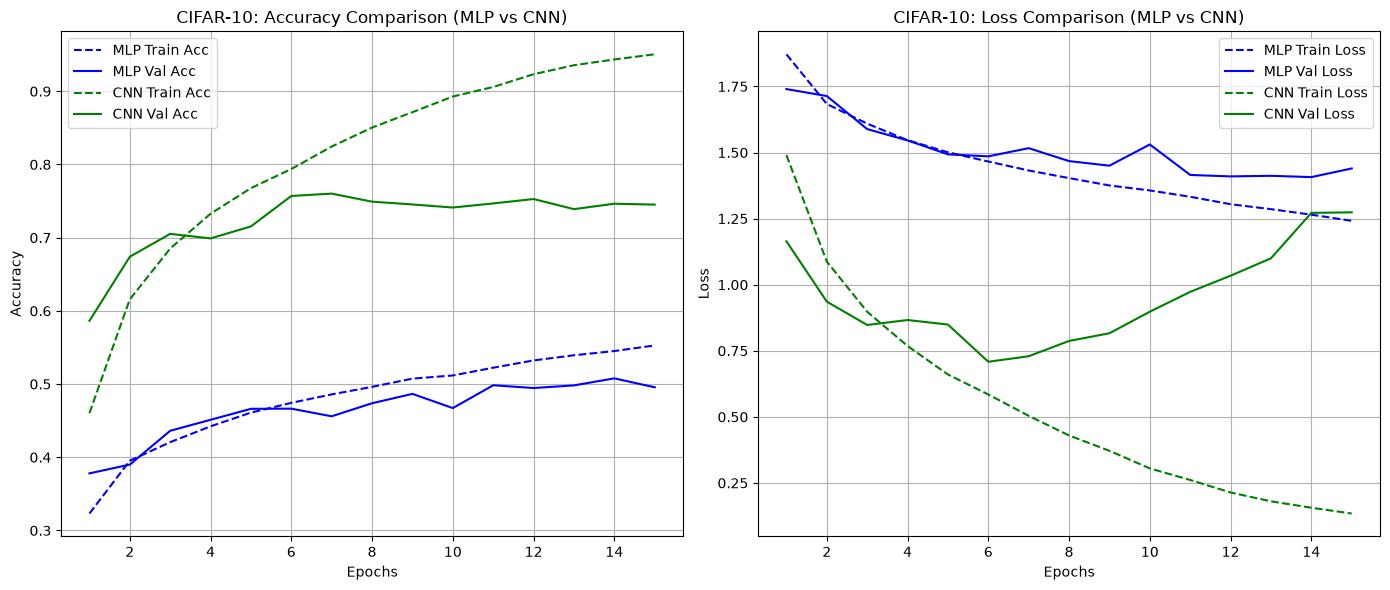


      CIFAR-10 FINAL EVALUATION SUMMARY
MLP Test Accuracy : 48.63%
CNN Test Accuracy : 73.65%
Accuracy Gain    : +25.02 percentage points


In [12]:
# 1. Load Data from Local Cache
(X_train_raw, y_train), (X_test_raw, y_test) = cifar10.load_data()

# CIFAR-10 class names for reference
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Preprocess & Normalize Pixel Values [0, 255] -> [0.0, 1.0]
X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

print(f"Dataset ready: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples.")

# -------------------------------------------------------------------
# MODEL 1: BASELINE MLP FOR CIFAR-10
# -------------------------------------------------------------------
print("\n" + "="*50)
print(" 1. BUILDING & TRAINING BASELINE MLP")
print("="*50)

model_mlp = Sequential([
    Flatten(input_shape=(32, 32, 3)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name="CIFAR10_MLP")

model_mlp.summary()

model_mlp.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_mlp = model_mlp.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss_mlp, test_acc_mlp = model_mlp.evaluate(X_test, y_test, verbose=0)


# -------------------------------------------------------------------
# MODEL 2: CONVOLUTIONAL NEURAL NETWORK (CNN)
# -------------------------------------------------------------------
print("\n" + "="*50)
print(" 2. BUILDING & TRAINING REPLACEMENT CNN")
print("="*50)

model_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Classification Head
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
], name="CIFAR10_CNN")

model_cnn.summary()

model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

test_loss_cnn, test_acc_cnn = model_cnn.evaluate(X_test, y_test, verbose=0)


# -------------------------------------------------------------------
# 3. PLOT COMPARISON CURVES
# -------------------------------------------------------------------
epochs = range(1, 16)
plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, history_mlp.history['accuracy'], 'b--', label='MLP Train Acc')
plt.plot(epochs, history_mlp.history['val_accuracy'], 'b-', label='MLP Val Acc')
plt.plot(epochs, history_cnn.history['accuracy'], 'g--', label='CNN Train Acc')
plt.plot(epochs, history_cnn.history['val_accuracy'], 'g-', label='CNN Val Acc')
plt.title('CIFAR-10: Accuracy Comparison (MLP vs CNN)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, history_mlp.history['loss'], 'b--', label='MLP Train Loss')
plt.plot(epochs, history_mlp.history['val_loss'], 'b-', label='MLP Val Loss')
plt.plot(epochs, history_cnn.history['loss'], 'g--', label='CNN Train Loss')
plt.plot(epochs, history_cnn.history['val_loss'], 'g-', label='CNN Val Loss')
plt.title('CIFAR-10: Loss Comparison (MLP vs CNN)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# -------------------------------------------------------------------
# 4. FINAL SUMMARY
# -------------------------------------------------------------------
print("\n" + "="*50)
print("      CIFAR-10 FINAL EVALUATION SUMMARY")
print("="*50)
print(f"MLP Test Accuracy : {test_acc_mlp * 100:.2f}%")
print(f"CNN Test Accuracy : {test_acc_cnn * 100:.2f}%")
print(f"Accuracy Gain    : +{(test_acc_cnn - test_acc_mlp) * 100:.2f} percentage points")
print("="*50)

In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.datasets import cifar10
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Load original partition
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# 2. Explicit Split: Split 50k train set into 42,500 Train and 7,500 Validation (85/15 split)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full
)

# 3. Scale pixel values [0, 255] -> [0.0, 1.0]
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

print(f"Train set shape      : {X_train.shape} ({X_train.shape[0]} samples)")
print(f"Validation set shape : {X_val.shape}   ({X_val.shape[0]} samples)")
print(f"Test set shape       : {X_test.shape}  ({X_test.shape[0]} samples)")

Train set shape      : (42500, 32, 32, 3) (42500 samples)
Validation set shape : (7500, 32, 32, 3)   (7500 samples)
Test set shape       : (10000, 32, 32, 3)  (10000 samples)


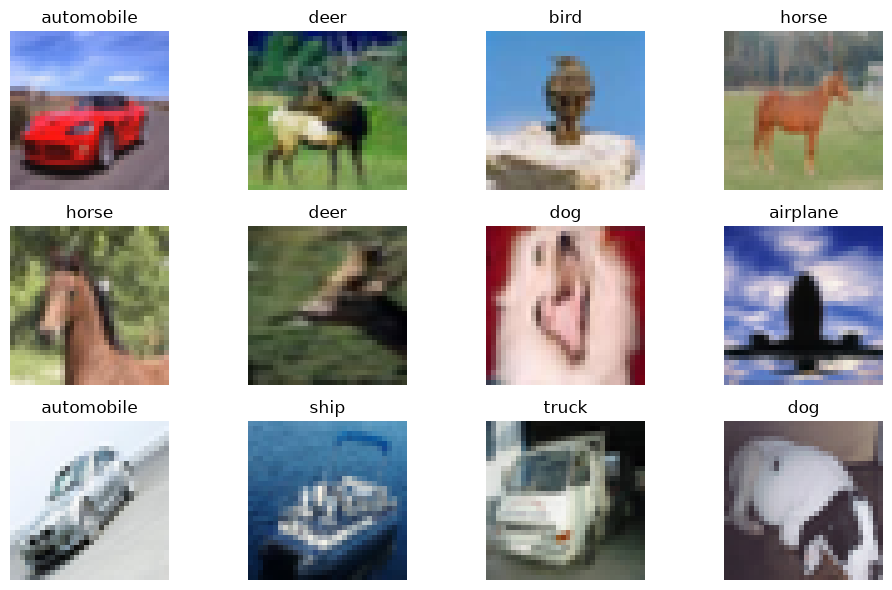

In [14]:
import matplotlib.pyplot as plt

class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [15]:
# 1. Real-time Data Augmentation Generator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train)

# 2. Enhanced CNN Architecture (VGG-style blocks + BatchNorm + Dropout)
model_enhanced_cnn = Sequential([
    # Block 1
    Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.35),

    # Block 3
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    Conv2D(128, (3, 3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.40),

    # Classification Head
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),
    Dense(10, activation='softmax')
], name="Enhanced_CIFAR10_CNN")

model_enhanced_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks for dynamic tuning
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
]

# 3. Fit Model on Augmented Data with Explicit Validation Set
batch_size = 64
history_enhanced = model_enhanced_cnn.fit(
    datagen.flow(X_train, y_train, batch_size=batch_size),
    epochs=25,
    steps_per_epoch=len(X_train) // batch_size,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
664/664 ━━━━━━━━━━━━━━━━━━━━ 71s 103ms/step - accuracy: 0.3869 - loss: 1.8256 - val_accuracy: 0.5165 - val_loss: 1.3644 - learning_rate: 0.0010
Epoch 2/25
  1/664 ━━━━━━━━━━━━━━━━━━━━ 1:14 112ms/step - accuracy: 0.4844 - loss: 1.3238

c:\Users\PC-LAB1\img_processing_lab\.imgvenv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4844 - loss: 1.3238 - val_accuracy: 0.5149 - val_loss: 1.3660 - learning_rate: 0.0010
Epoch 3/25
664/664 ━━━━━━━━━━━━━━━━━━━━ 68s 103ms/step - accuracy: 0.5278 - loss: 1.3227 - val_accuracy: 0.5528 - val_loss: 1.3456 - learning_rate: 0.0010
Epoch 4/25
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6250 - loss: 1.1433 - val_accuracy: 0.5533 - val_loss: 1.3151 - learning_rate: 0.0010
Epoch 5/25
664/664 ━━━━━━━━━━━━━━━━━━━━ 64s 97ms/step - accuracy: 0.5940 - loss: 1.1434 - val_accuracy: 0.6632 - val_loss: 0.9838 - learning_rate: 0.0010
Epoch 6/25
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5469 - loss: 1.3293 - val_accuracy: 0.6639 - val_loss: 0.9780 - learning_rate: 0.0010
Epoch 7/25
664/664 ━━━━━━━━━━━━━━━━━━━━ 63s 94ms/step - accuracy: 0.6348 - loss: 1.0371 - val_accuracy: 0.6453 - val_loss: 1.0680 - learning_rate: 0.0010
Epoch 8/25
664/664 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6719 - loss: 1.0355 - val_

KeyboardInterrupt: 

     ENHANCED CNN UNSEEN TEST EVALUATION
Test Loss     : 0.7479
Test Accuracy : 75.06%


NameError: name 'history_enhanced' is not defined

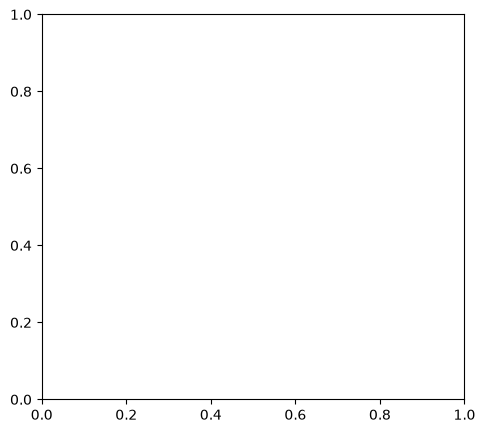

In [16]:
# Evaluate purely on the unseen test dataset
test_loss, test_acc = model_enhanced_cnn.evaluate(X_test, y_test, verbose=0)

print("="*50)
print("     ENHANCED CNN UNSEEN TEST EVALUATION")
print("="*50)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc * 100:.2f}%")
print("="*50)

# Plot Training vs Validation History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_enhanced.history['accuracy'], label='Train Acc')
plt.plot(history_enhanced.history['val_accuracy'], label='Val Acc')
plt.title('Enhanced CNN: Accuracy History')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_enhanced.history['loss'], label='Train Loss')
plt.plot(history_enhanced.history['val_loss'], label='Val Loss')
plt.title('Enhanced CNN: Loss History (Regularized)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()